# GROMACS Performance Benchmarking

Scratch analysis of GROMACS run speed (ns/day) on Alpine (CURC) across
core count, thread/task split (`ntomp` vs `ntasks`), PME grid size, and
box shape (cube vs dodecahedron), for several test sequences. Each cell is
a self-contained benchmark: raw per-replicate speed arrays, a
mean/std summary, and (where applicable) a comparison plot. Not part of
the production analysis pipeline.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [2]:
# cpus-per-task only, no dd
cores_cpus = np.array([4, 8, 12, 16, 20, 24, 28, 32, 64])
speed_cpus = np.array([24.961, 47.826, 60.360, 79.011, 57.099, 82.110, 74.656, 119.507, 180.971])

# ntomp = 1 = cpus-per-task, vary ntasks
cores_1omp = np.array([4, 8, 12, 16, 20, 24, 28, 32, 40, 48, 56, 60, 64])
#speed_1omp_25ns = np.array([47.101, 78.455, 111.195, 129.367, 152.871, 204.296, 200.313, 144.693, 154.118, 147.144, 288.928, 309.422, 332.510])
speed_1omp_50ns_rep1 = np.array([41.703, 77.438, 95.743, 118.015, 162.176, 185.373, 238.042, 194.500, 253.887, 269.603, 296.395, 321.937, 202.236])
speed_1omp_50ns_rep2 = np.array([40.220, 79.204, 122.836, 137.79, 149.395, 137.631, 168.361, 180.776, 250.730, 288.692, 303.371, 301.919, 149.336])
speed_1omp_50ns_rep3 = np.array([45.205, 92.801, 111.496, 142.647, 141.324, 168.47, 160.867, 188.330, 259.305, 294.554, 275.456, 240.544, 108.277])
speed_1omp_50ns_avg = np.mean(np.array([speed_1omp_50ns_rep1, speed_1omp_50ns_rep2, speed_1omp_50ns_rep3]), axis=0)
speed_1omp_50ns_std = np.std(np.array([speed_1omp_50ns_rep1, speed_1omp_50ns_rep2, speed_1omp_50ns_rep3]), axis=0)

# ntomp = 2 = cpus-per-task, vary ntasks
cores_2omp = np.array([4, 8, 12, 16, 20, 24, 28, 32, 64])
#speed_2omp_25ns = np.array([25.652, 38.461, 54.783, 70.074, 105.772, 121.096, 109.432, 146.745, 220.855])
speed_2omp_50ns_rep1 = np.array([25.311, 48.409, 68.207, 88.908, 103.838, 94.476, 109.871, 121.992, 204.687])
speed_2omp_50ns_rep2 = np.array([20.401, 49.537, 54.200, 70.935, 84.285, 97.391, 107.586, 108.506, 202.689])
speed_2omp_50ns_rep3 = np.array([25.817, 38.783, 55.148, 71.464, 83.764, 97.572, 109.572, 122.396, 208.027])
speed_2omp_50ns_avg = np.mean(np.array([speed_2omp_50ns_rep1, speed_2omp_50ns_rep2, speed_2omp_50ns_rep3]), axis=0)
speed_2omp_50ns_std = np.std(np.array([speed_2omp_50ns_rep1, speed_2omp_50ns_rep2, speed_2omp_50ns_rep3]), axis=0)

# ntomp = 4 = cpus-per-task, vary ntasks
cores_4omp = np.array([4, 8, 12, 16, 20, 24, 28, 32, 64])
#speed_4omp_25ns = np.array([10.812, 19.246, 27.853, 32.418, 37.757, 50.010, 54.932, 79.625, 100.883])
speed_4omp_50ns_rep1 = np.array([14.001, 19.500, 27.482, 46.053, 42.883, 63.576, 71.441, 61.822, 100.676])
speed_4omp_50ns_rep2 = np.array([10.718, 23.846, 24.243, 34.374, 42.966, 49.982, 47.380, 63.517, 100.883])
speed_4omp_50ns_rep3 = np.array([10.663, 24.531, 26.616, 35.433, 41.939, 47.130, 55.477, 62.059, 101.178])
speed_4omp_50ns_avg = np.mean(np.array([speed_4omp_50ns_rep1, speed_4omp_50ns_rep2, speed_4omp_50ns_rep3]), axis=0)
speed_4omp_50ns_std = np.std(np.array([speed_4omp_50ns_rep1, speed_4omp_50ns_rep2, speed_4omp_50ns_rep3]), axis=0)

#########
# ntasks = 1, vary ntomp
cores_1rank = np.array([4, 8, 12, 16, 20, 24, 28, 32, 64])
speed_1rank_25ps = np.array([10.777, 10.503, 10.172, 7.976, 9.625, 8.566, 9.006, 11.088, 7.360])
#speed_1rank_50ps = np.array([8.821, 7.330])

# ntasks = 2, vary ntomp
cores_2rank = np.array([4, 8, 12, 16, 20, 24, 28, 32, 64])
speed_2rank_25ps = np.array([20.265, 16.957, 23.598, 17.086, 18.887, 21.477, 16.302, 20.089, 12.555])

# ntasks = 4, vary ntomp
cores_4rank = np.array([4, 8, 12, 16, 20, 24, 28, 32, 64])
speed_4rank_25ps = np.array([41.000, 38.447, 41.690, 35.502, 32.721, 42.736, 32.417, 33.340, 25.527])

Text(0.5, 1.0, 'seq6, 50ps benchmarking')

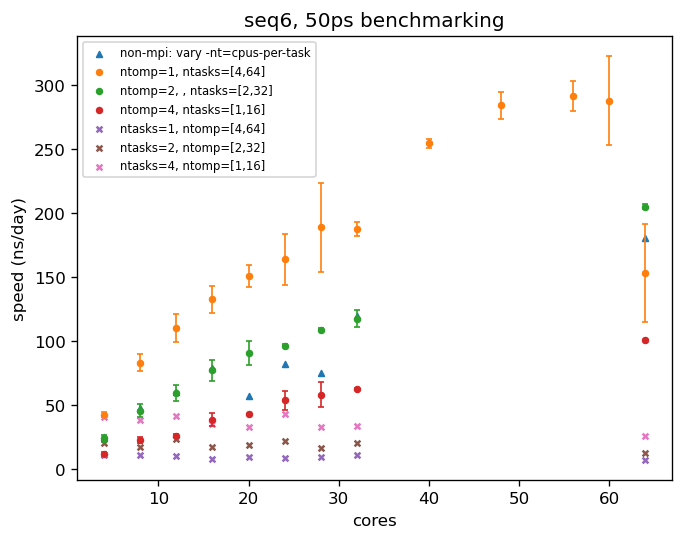

In [3]:
fig = plt.figure(dpi=120)

markersize=12
plt.scatter(cores_cpus, speed_cpus, marker='^', s=markersize, label='non-mpi: vary -nt=cpus-per-task')
plt.scatter(cores_1omp, speed_1omp_50ns_avg, s=markersize, color='C1', label='ntomp=1, ntasks=[4,64]')
plt.errorbar(cores_1omp, speed_1omp_50ns_avg, yerr=speed_1omp_50ns_std, fmt='o', ms=3, capsize=2, elinewidth=1, color='C1')
plt.scatter(cores_2omp, speed_2omp_50ns_avg, s=markersize, color='C2', label='ntomp=2, , ntasks=[2,32]')
plt.errorbar(cores_2omp, speed_2omp_50ns_avg, yerr=speed_2omp_50ns_std, fmt='o', ms=3, capsize=2, elinewidth=1, color='C2')
plt.scatter(cores_4omp, speed_4omp_50ns_avg, s=markersize, color='C3', label='ntomp=4, ntasks=[1,16]')
plt.errorbar(cores_4omp, speed_4omp_50ns_avg, yerr=speed_4omp_50ns_std, fmt='o', ms=3, capsize=2, elinewidth=1, color='C3')

plt.scatter(cores_1rank, speed_1rank_25ps, marker='x', s=markersize, color='C4', label='ntasks=1, ntomp=[4,64]')
plt.scatter(cores_2rank, speed_2rank_25ps, marker='x', s=markersize, color='C5', label='ntasks=2, ntomp=[2,32]')
plt.scatter(cores_4rank, speed_4rank_25ps, marker='x', s=markersize, color='C6', label='ntasks=4, ntomp=[1,16]')

plt.legend(loc='best', fontsize=7)
plt.xlabel('cores')
plt.ylabel('speed (ns/day)')
plt.title('seq6, 50ps benchmarking')

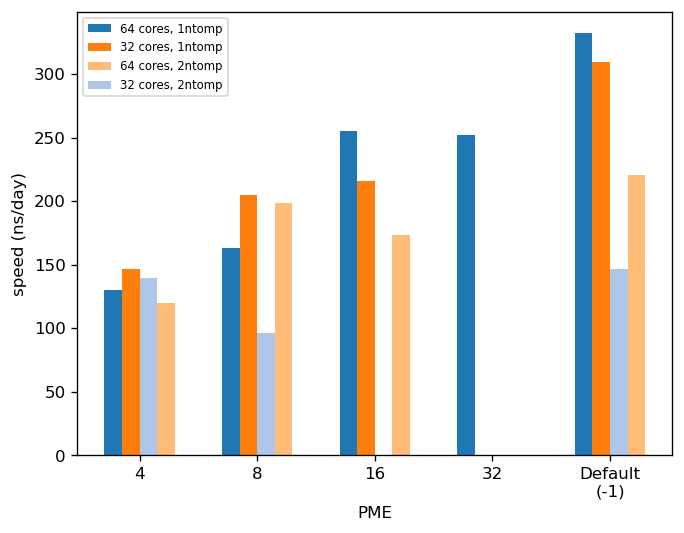

In [4]:
PME = ['4', '8', '16', '32', 'Default\n(-1)']
speed_PME_64cores_1ntomp = np.array([130.376, 163.305, 255.575, 251.744, 332.510])
speed_PME_32cores_1ntomp = np.array([146.668, 204.952, 215.631, 0, 309.422])
speed_PME_64cores_2ntomp = np.array([119.618, 198.597, 173.296, 0, 220.855])
speed_PME_32cores_2ntomp = np.array([139.677, 96.072, 0, 0, 146.745])

ind = np.arange(len(PME)) 
width = 0.15

fig, ax = plt.subplots(dpi=120)

rects1 = ax.bar(ind - 1.5*width, speed_PME_64cores_1ntomp, width, color='#1f77b4', label='64 cores, 1ntomp')
rects2 = ax.bar(ind - 0.5*width, speed_PME_32cores_1ntomp, width, color='#ff7f0e', label='32 cores, 1ntomp')
rects3 = ax.bar(ind + 1.5*width, speed_PME_64cores_2ntomp, width, color='#ffbb78', label='64 cores, 2ntomp')
rects4 = ax.bar(ind + 0.5*width, speed_PME_32cores_2ntomp, width, color='#aec7e8', label='32 cores, 2ntomp')

ax.set_ylabel('speed (ns/day)')
ax.set_xlabel('PME')
ax.set_xticks(ind)
ax.set_xticklabels(PME) 
ax.legend(loc='best', fontsize=7)
plt.show()

In [5]:
# seq14, 50ps, dt=0.003
cores_1omp_seq14 = np.array([4, 8, 12, 16, 20, 24, 28, 32, 40, 48, 56, 60, 64])
speed_1omp_seq14_50ns_rep1 = np.array([31.381, 76.489, 104.882, 92.295, 100.131, 124.050, 176.265, 164.374, 173.461, 194.795, 221.146, 208.489, 133.075])
speed_1omp_seq14_50ns_rep2 = np.array([31.565, 56.264, 76.753, 73.785, 93.617, 140.130, 115.149, 154.134, 117.320, 192.043, 237.109, 219.679, 80.158])
speed_1omp_seq14_50ns_rep3 = np.array([31.381, 55.989, 105.759, 79.004, 94.613, 118.906, 130.873, 165.199, 180.260, 213.345, 156.456, 188.325, 125.791])
speed_1omp_seq14_50ns_avg = np.mean(np.array([speed_1omp_seq14_50ns_rep1, speed_1omp_seq14_50ns_rep2, speed_1omp_seq14_50ns_rep3]), axis=0)
speed_1omp_seq14_50ns_std = np.std(np.array([speed_1omp_seq14_50ns_rep1, speed_1omp_seq14_50ns_rep2, speed_1omp_seq14_50ns_rep3]), axis=0)

In [6]:
# seq16, 50ps, dt=0.003
cores_1omp_seq16 = np.array([4, 8, 12, 16, 20, 24, 28, 32, 40, 48, 56, 60, 64])
speed_1omp_seq16_50ns_rep1 = np.array([24.699, 53.567, 64.895, 96.639, 121.617, 112.442, 153.238, 168.473, 184.755, 210.028, 250.7, 
                                       256.266, 262.592])
speed_1omp_seq16_50ns_rep2 = np.array([28.692, 55.916, 68.46, 95.665, 122.077, 135.821, 155.411, 167.175, 184.638, 195.588, 232.64, 
                                       236.685, 244.282])
speed_1omp_seq16_50ns_rep3 = np.array([30.595, 57.772, 65.274, 105.933, 110.209, 106.582, 129.046, 159.987, 188.476, 220.56, 255.778,
                                       248.366, 264.14])
speed_1omp_seq16_50ns_avg = np.mean(np.array([speed_1omp_seq16_50ns_rep1, speed_1omp_seq16_50ns_rep2, speed_1omp_seq16_50ns_rep3]), axis=0)
speed_1omp_seq16_50ns_std = np.std(np.array([speed_1omp_seq16_50ns_rep1, speed_1omp_seq16_50ns_rep2, speed_1omp_seq16_50ns_rep3]), axis=0)

In [7]:
# seq2, 50ps, dt=0.003
cores_1omp_seq2 = np.array([4, 8, 12, 16, 20, 24, 28, 32, 40, 48, 56, 60, 64])
speed_1omp_seq2_50ns_rep1 = np.array([37.537, 58.678, 80.207, 105.797, 109.389, 89.724, 112.179, 165.798, 199.17, 204.488, 243.885,
                                      240.738, 254.634])
speed_1omp_seq2_50ns_rep2 = np.array([30.556, 57.609, 64.285, 95.683, 88.755, 91.304, 145.559, 174.909, 182.983, 222.146, 218.597,
                                      197.409, 249.684])
speed_1omp_seq2_50ns_rep3 = np.array([28.492, 55.469, 76.334, 94.739, 93.229, 99.900, 167.015, 145.595, 181.061, 209.978, 246.683,
                                      220.799, 255.974])
speed_1omp_seq2_50ns_avg = np.mean(np.array([speed_1omp_seq2_50ns_rep1, speed_1omp_seq2_50ns_rep2, speed_1omp_seq2_50ns_rep3]), axis=0)
speed_1omp_seq2_50ns_std = np.std(np.array([speed_1omp_seq2_50ns_rep1, speed_1omp_seq2_50ns_rep2, speed_1omp_seq2_50ns_rep3]), axis=0)

Text(0.5, 1.0, 'system benchmarking\nntomp=1, ntasks=[4,64], 50ps, avg of 3 replicates')

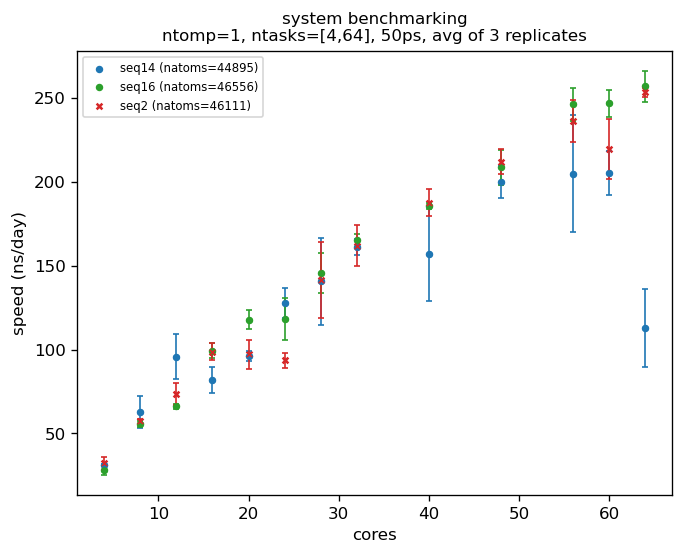

In [8]:
fig = plt.figure(dpi=120)

markersize=12
plt.scatter(cores_1omp_seq14, speed_1omp_seq14_50ns_avg, s=markersize, color='C0', label='seq14 (natoms=44895)')
plt.errorbar(cores_1omp_seq14, speed_1omp_seq14_50ns_avg, yerr=speed_1omp_seq14_50ns_std, fmt='o', ms=3, capsize=2, elinewidth=1, color='C0')

# plt.scatter(cores_1omp, speed_1omp_50ns_avg, s=markersize, color='C1', label='seq6 (natoms=44962)')
# plt.errorbar(cores_1omp, speed_1omp_50ns_avg, yerr=speed_1omp_50ns_std, fmt='o', ms=3, capsize=2, elinewidth=1, color='C1')

plt.scatter(cores_1omp_seq16, speed_1omp_seq16_50ns_avg, s=markersize, color='C2', label='seq16 (natoms=46556)')
plt.errorbar(cores_1omp_seq16, speed_1omp_seq16_50ns_avg, yerr=speed_1omp_seq16_50ns_std, fmt='o', ms=3, capsize=2, elinewidth=1, color='C2')

plt.scatter(cores_1omp_seq2, speed_1omp_seq2_50ns_avg, marker='x', s=markersize, color='C3', label='seq2 (natoms=46111)')
plt.errorbar(cores_1omp_seq2, speed_1omp_seq2_50ns_avg, yerr=speed_1omp_seq2_50ns_std, fmt='x', ms=3, capsize=2, elinewidth=1, color='C3')

plt.legend(loc='best', fontsize=7)
plt.xlabel('cores')
plt.ylabel('speed (ns/day)')
plt.title('system benchmarking\nntomp=1, ntasks=[4,64], 50ps, avg of 3 replicates', fontsize=10)

In [9]:
# seq1 (nonbinder), 100ps, dt=0.003
cores_1omp_seq1_100ps = np.array([32, 48, 64])
speed_1omp_seq1_100ps_rep1 = np.array([126.562, 195.228, 242.075])
speed_1omp_seq1_100ps_rep2 = np.array([122.584, 187.487, 248.041])
speed_1omp_seq1_100ps_rep3 = np.array([132.722, 175.917, 256.818])
speed_1omp_seq1_100ps_rep4 = np.array([128.272, 171.826, 254.186])
speed_1omp_seq1_100ps_rep5 = np.array([154.699, 176.061, 251.24])
speed_1omp_seq1_100ps_rep6 = np.array([161.635, 210.613, 229.086])
speed_1omp_seq1_100ps_rep7 = np.array([130.588, 195.058, 242.926])
speed_1omp_seq1_100ps_rep8 = np.array([159.273, 191.097, 224.839])
speed_1omp_seq1_100ps_rep9 = np.array([125.938, 192.493, 239.958])
speed_1omp_seq1_100ps_rep10 = np.array([126.462, 193.487, 246.71])

speed_1omp_seq1_100ps_avg = np.mean(np.array([speed_1omp_seq1_100ps_rep1, speed_1omp_seq1_100ps_rep2, speed_1omp_seq1_100ps_rep3,
                                              speed_1omp_seq1_100ps_rep4, speed_1omp_seq1_100ps_rep5, speed_1omp_seq1_100ps_rep6,
                                              speed_1omp_seq1_100ps_rep7, speed_1omp_seq1_100ps_rep8, speed_1omp_seq1_100ps_rep9,
                                              speed_1omp_seq1_100ps_rep10]), axis=0)
speed_1omp_seq1_100ps_std = np.std(np.array([speed_1omp_seq1_100ps_rep1, speed_1omp_seq1_100ps_rep2, speed_1omp_seq1_100ps_rep3,
                                             speed_1omp_seq1_100ps_rep4, speed_1omp_seq1_100ps_rep5, speed_1omp_seq1_100ps_rep6,
                                             speed_1omp_seq1_100ps_rep7, speed_1omp_seq1_100ps_rep8, speed_1omp_seq1_100ps_rep9,
                                             speed_1omp_seq1_100ps_rep10]), axis=0)

In [10]:
# seq2 (nonbinder), 100ps, dt=0.003
cores_1omp_seq2_100ps = np.array([32, 48, 64])
speed_1omp_seq2_100ps_rep1 = np.array([123.148, 201.989, 219.422])
speed_1omp_seq2_100ps_rep2 = np.array([120.32, 193.674, 236.129])
speed_1omp_seq2_100ps_rep3 = np.array([115.159, 167.655, 220.2])
speed_1omp_seq2_100ps_rep4 = np.array([152.02,  208.229, 231.942])
speed_1omp_seq2_100ps_rep5 = np.array([115.495, 170.796, 241.695])
speed_1omp_seq2_100ps_rep6 = np.array([126.566, 193.188, 240.496])
speed_1omp_seq2_100ps_rep7 = np.array([120.103, 182.223, 245.824])
speed_1omp_seq2_100ps_rep8 = np.array([122.836, 163.95, 234.034])
speed_1omp_seq2_100ps_rep9 = np.array([130.015, 193.444, 234.755])
speed_1omp_seq2_100ps_rep10 = np.array([118.229, 191.699, 235.804])

speed_1omp_seq2_100ps_avg = np.mean(np.array([speed_1omp_seq2_100ps_rep1, speed_1omp_seq2_100ps_rep2, speed_1omp_seq2_100ps_rep3,
                                              speed_1omp_seq2_100ps_rep4, speed_1omp_seq2_100ps_rep5, speed_1omp_seq2_100ps_rep6,
                                              speed_1omp_seq2_100ps_rep7, speed_1omp_seq2_100ps_rep8, speed_1omp_seq2_100ps_rep9,
                                              speed_1omp_seq2_100ps_rep10]), axis=0)
speed_1omp_seq2_100ps_std = np.std(np.array([speed_1omp_seq2_100ps_rep1, speed_1omp_seq2_100ps_rep2, speed_1omp_seq2_100ps_rep3,
                                              speed_1omp_seq2_100ps_rep4, speed_1omp_seq2_100ps_rep5, speed_1omp_seq2_100ps_rep6,
                                              speed_1omp_seq2_100ps_rep7, speed_1omp_seq2_100ps_rep8, speed_1omp_seq2_100ps_rep9,
                                              speed_1omp_seq2_100ps_rep10]), axis=0)

In [11]:
# seq14 (binder), 100ps, dt=0.003
cores_1omp_seq14_100ps = np.array([32, 48, 64])
speed_1omp_seq14_100ps_rep1 = np.array([138.715, 214.445, 252.177])
speed_1omp_seq14_100ps_rep2 = np.array([159.135, 211.018, 255.54])
speed_1omp_seq14_100ps_rep3   = np.array([155.572, 203.867, 242.165])
speed_1omp_seq14_100ps_rep4   = np.array([156.465, 211.728, 256.412])
speed_1omp_seq14_100ps_rep5   = np.array([143.933, 212.031, 238.275])
speed_1omp_seq14_100ps_rep6   = np.array([172.108, 208.586, 253.601])
speed_1omp_seq14_100ps_rep7   = np.array([123.79, 195.278, 257.102])
speed_1omp_seq14_100ps_rep8   = np.array([108.359, 205.983, 257.255])
speed_1omp_seq14_100ps_rep9   = np.array([128.787, 194.977, 230.748])
speed_1omp_seq14_100ps_rep10   = np.array([128.727, 216.217, 230.006])

speed_1omp_seq14_100ps_avg = np.mean(np.array([speed_1omp_seq14_100ps_rep1, speed_1omp_seq14_100ps_rep2, speed_1omp_seq14_100ps_rep3,
                                              speed_1omp_seq14_100ps_rep4, speed_1omp_seq14_100ps_rep5, speed_1omp_seq14_100ps_rep6,
                                              speed_1omp_seq14_100ps_rep7, speed_1omp_seq14_100ps_rep8, speed_1omp_seq14_100ps_rep9,
                                              speed_1omp_seq14_100ps_rep10]), axis=0)
speed_1omp_seq14_100ps_std = np.std(np.array([speed_1omp_seq14_100ps_rep1, speed_1omp_seq14_100ps_rep2, speed_1omp_seq14_100ps_rep3,
                                              speed_1omp_seq14_100ps_rep4, speed_1omp_seq14_100ps_rep5, speed_1omp_seq14_100ps_rep6,
                                              speed_1omp_seq14_100ps_rep7, speed_1omp_seq14_100ps_rep8, speed_1omp_seq14_100ps_rep9,
                                              speed_1omp_seq14_100ps_rep10]), axis=0)

In [12]:
# seq16 (binder), 100ps, dt=0.003
cores_1omp_seq16_100ps = np.array([32, 48, 64])
speed_1omp_seq16_100ps_rep1   = np.array([158.329, 209.137, 236.654])
speed_1omp_seq16_100ps_rep2   = np.array([150.612, 198.787, 248.506])
speed_1omp_seq16_100ps_rep3   = np.array([117.818, 213.206, 234.779])
speed_1omp_seq16_100ps_rep4   = np.array([126.042, 197.54, 237.706])
speed_1omp_seq16_100ps_rep5   = np.array([153.294, 190.439, 220.914])
speed_1omp_seq16_100ps_rep6   = np.array([131.01, 176.116, 239.453])
speed_1omp_seq16_100ps_rep7   = np.array([117.86, 194.819, 244.397])
speed_1omp_seq16_100ps_rep8   = np.array([146.001, 177.211, 246.329])
speed_1omp_seq16_100ps_rep9   = np.array([135.755, 164.581, 252.496])
speed_1omp_seq16_100ps_rep10   = np.array([123.997, 203.463, 247.881])

speed_1omp_seq16_100ps_avg = np.mean(np.array([speed_1omp_seq16_100ps_rep1, speed_1omp_seq16_100ps_rep2, speed_1omp_seq16_100ps_rep3,
                                              speed_1omp_seq16_100ps_rep4, speed_1omp_seq16_100ps_rep5, speed_1omp_seq16_100ps_rep6,
                                              speed_1omp_seq16_100ps_rep7, speed_1omp_seq16_100ps_rep8, speed_1omp_seq16_100ps_rep9,
                                              speed_1omp_seq16_100ps_rep10]), axis=0)
speed_1omp_seq16_100ps_std = np.std(np.array([speed_1omp_seq16_100ps_rep1, speed_1omp_seq16_100ps_rep2, speed_1omp_seq16_100ps_rep3,
                                              speed_1omp_seq16_100ps_rep4, speed_1omp_seq16_100ps_rep5, speed_1omp_seq16_100ps_rep6,
                                              speed_1omp_seq16_100ps_rep7, speed_1omp_seq16_100ps_rep8, speed_1omp_seq16_100ps_rep9,
                                              speed_1omp_seq16_100ps_rep10]), axis=0)

Text(0.5, 1.0, 'system benchmarking\nntomp=1, ntasks=[32, 48, 64], 100ps, avg of 10 replicates')

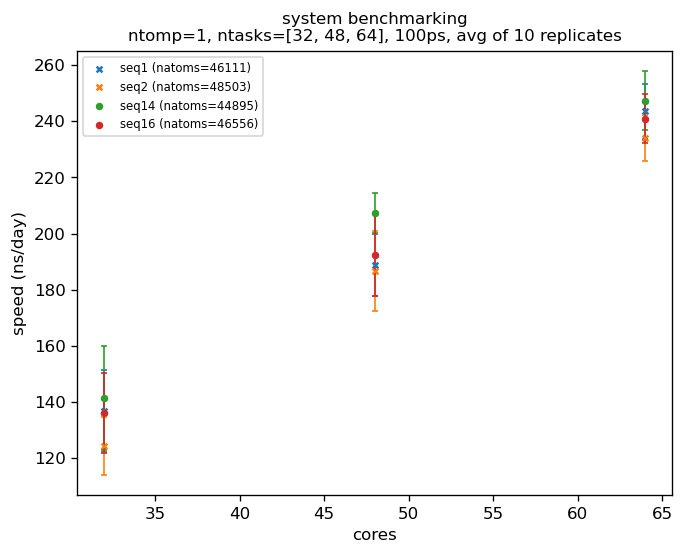

In [13]:
fig = plt.figure(dpi=120)

markersize=12
plt.scatter(cores_1omp_seq1_100ps, speed_1omp_seq1_100ps_avg, marker='x', s=markersize, color='C0', label='seq1 (natoms=46111)')
plt.errorbar(cores_1omp_seq1_100ps, speed_1omp_seq1_100ps_avg, yerr=speed_1omp_seq1_100ps_std, fmt='x', ms=3, capsize=2, elinewidth=1, color='C0')

plt.scatter(cores_1omp_seq2_100ps, speed_1omp_seq2_100ps_avg, marker='x', s=markersize, color='C1', label='seq2 (natoms=48503)')
plt.errorbar(cores_1omp_seq2_100ps, speed_1omp_seq2_100ps_avg, yerr=speed_1omp_seq2_100ps_std, fmt='x', ms=3, capsize=2, elinewidth=1, color='C1')

plt.scatter(cores_1omp_seq14_100ps, speed_1omp_seq14_100ps_avg, marker='o', s=markersize, color='C2', label='seq14 (natoms=44895)')
plt.errorbar(cores_1omp_seq14_100ps, speed_1omp_seq14_100ps_avg, yerr=speed_1omp_seq14_100ps_std, fmt='o', ms=3, capsize=2, elinewidth=1, color='C2')

plt.scatter(cores_1omp_seq16_100ps, speed_1omp_seq16_100ps_avg, marker='o', s=markersize, color='C3', label='seq16 (natoms=46556)')
plt.errorbar(cores_1omp_seq16_100ps, speed_1omp_seq16_100ps_avg, yerr=speed_1omp_seq16_100ps_std, fmt='o', ms=3, capsize=2, elinewidth=1, color='C3')

plt.legend(loc='best', fontsize=7)
plt.xlabel('cores')
plt.ylabel('speed (ns/day)')
plt.title('system benchmarking\nntomp=1, ntasks=[32, 48, 64], 100ps, avg of 10 replicates', fontsize=10)

In [14]:
# Dodecahedron (seq16, 100ps, dt=0.003)
cores_1omp_seq16_100ps_d12 = np.array([32, 48, 64])
speed_1omp_seq16_100ps_d12_rep1 = np.array([154.123, 148.602, 152.174])
speed_1omp_seq16_100ps_d12_rep2 = np.array([148.578, 172.996, 181.007])
speed_1omp_seq16_100ps_d12_rep3 = np.array([141.476, 178.308, 200.987])
speed_1omp_seq16_100ps_d12_avg = np.mean(np.array([speed_1omp_seq16_100ps_d12_rep1, speed_1omp_seq16_100ps_d12_rep2, speed_1omp_seq16_100ps_d12_rep3]), axis=0)
speed_1omp_seq16_100ps_d12_std = np.std(np.array([speed_1omp_seq16_100ps_d12_rep1, speed_1omp_seq16_100ps_d12_rep2, speed_1omp_seq16_100ps_d12_rep3]), axis=0)

In [15]:
# Dodecahedron (seq16, 100ps, dt=0.003)
print(np.mean([291.159, 265.587, 259.062, 275.563, 270.205])) # dd=443
print(np.mean([259.342, 266.260, 251.661])) # dd=462
print(np.mean([275.731, 257.602, 282.765, 270.211, 270.203])) # dd=642
print(np.mean([259.461, 267.344, 262.196])) # dd=832
print(np.mean([241.748, 259.970, 259.387])) # dd=823

272.3152
259.0876666666666
271.3024
263.00033333333334
253.70166666666668


In [16]:
# Dodecahedron (seq2, 100ps, dt=0.003)
print(np.mean([249.572, 145.374, 254.980, 261.692, 243.014])) # dd=443
print(np.mean([217.008, 285.069, 214.174, 271.967, 272.330])) # dd=642

print(np.mean([172.197, 171.694, 176.826])) # PME=8
print(np.mean([271.798, 266.953, 171.294])) # PME=16
print(np.mean([165.072, 200.571, 187.021])) # PME=24

230.9264
252.1096
173.57233333333332
236.68166666666664
184.22133333333332
